# Business Entity Resolution — Exploratory Data Analysis (EDA)
### Amazon ML Challenge 2026 — Phase 1

This notebook performs a comprehensive, rigorous exploratory data analysis of the 3 business entity data sources (`train_source1.tsv`, `train_source2.tsv`, `train_source3.tsv`) and the ground truth matching file (`train_ground_truth.tsv`).

**Core Objectives:**
1. **Sanity Check:** Audit dataset shapes, missing values, duplicates, and prefix integrity.
2. **Ground Truth Analysis:** Evaluate singleton rates, match count distributions, and noise/distractor rates in external sources.
3. **Country Analysis:** Verify country distributions and document generalization constraints (unseen countries).
4. **Noise Cataloging:** Systematically analyze name and address variations across true matches.
5. **Statistical Characterization:** Compute token and character length distributions to guide downstream blocking window design.
6. **Noise Record Audit:** Characterize unreferenced external records.


In [1]:
import os
import gc
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica, Arial, DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 120

os.makedirs('eda_assets', exist_ok=True)
print("Environment and dependencies initialized successfully.")


Environment and dependencies initialized successfully.


---
## TASK 1: Load and Sanity-Check the Data

We load all 4 training files using explicit `sep='\t'` (tab-separated) to prevent naive comma-delimited parsing errors.


In [2]:
# File paths
s1_path = '../dataset/train/train_source1.tsv' if os.path.exists('../dataset') else 'dataset/train/train_source1.tsv'
s2_path = '../dataset/train/train_source2.tsv' if os.path.exists('../dataset') else 'dataset/train/train_source2.tsv'
s3_path = '../dataset/train/train_source3.tsv' if os.path.exists('../dataset') else 'dataset/train/train_source3.tsv'
gt_path = '../dataset/train/train_ground_truth.tsv' if os.path.exists('../dataset') else 'dataset/train/train_ground_truth.tsv'

# Load Source 1 (Reference) and Ground Truth
print("Loading Source 1 and Ground Truth...")
df_s1 = pd.read_csv(s1_path, sep='\t')
df_gt = pd.read_csv(gt_path, sep='\t')

print(f"Source 1 Shape: {df_s1.shape[0]:,} rows, {df_s1.shape[1]} columns")
print(f"Ground Truth Shape: {df_gt.shape[0]:,} rows, {df_gt.shape[1]} columns")


Loading Source 1 and Ground Truth...


Source 1 Shape: 2,206,821 rows, 4 columns
Ground Truth Shape: 2,206,821 rows, 2 columns


In [3]:
# Inspect S1 and Ground Truth info & nulls
print("--- Source 1 Data Quality ---")
print("Null values:\n", df_s1.isnull().sum())
print("Duplicate entity_ids:", df_s1['entity_id'].duplicated().sum())
print("All entity_ids start with 'S1-':", df_s1['entity_id'].str.startswith('S1-').all())

print("\n--- Ground Truth Data Quality ---")
print("Null values in ground truth:\n", df_gt.isnull().sum())
print("Duplicate source1_entity_ids:", df_gt['source1_entity_id'].duplicated().sum())
print("All source1_entity_ids start with 'S1-':", df_gt['source1_entity_id'].str.startswith('S1-').all())


--- Source 1 Data Quality ---
Null values:
 entity_id           0
business_name       0
business_address    0
country             0
dtype: int64


Duplicate entity_ids: 0
All entity_ids start with 'S1-': True

--- Ground Truth Data Quality ---


Null values in ground truth:
 source1_entity_id          0
matched_entity_ids    123247
dtype: int64
Duplicate source1_entity_ids: 0
All source1_entity_ids start with 'S1-': True


---
## TASK 2: Ground Truth Structure Analysis

We parse `matched_entity_ids` (comma-separated list) for each Source 1 entity and compute:
- Singleton rate (0 matches)
- Single match rate (exactly 1 match)
- Multi-match rate ($\ge 2$ matches)
- Match count distribution histogram
- S2 vs S3 match representation
- Cross-file consistency & orphaned reference audit
- External source noise rate (unreferenced records)


In [4]:
# Parse matched_entity_ids into Python lists
def parse_matches(val):
    if pd.isna(val) or str(val).strip() == '':
        return []
    return [x.strip() for x in str(val).split(',') if x.strip()]

df_gt['matches_list'] = df_gt['matched_entity_ids'].apply(parse_matches)
df_gt['match_count'] = df_gt['matches_list'].apply(len)

total_s1 = len(df_gt)
singletons = int((df_gt['match_count'] == 0).sum())
one_match = int((df_gt['match_count'] == 1).sum())
multi_match = int((df_gt['match_count'] >= 2).sum())

print(f"a) Total S1 entities in Ground Truth: {total_s1:,}")
print(f"b) Singletons (0 matches): {singletons:,} ({singletons/total_s1*100:.2f}%)")
print(f"c) Exactly 1 Match: {one_match:,} ({one_match/total_s1*100:.2f}%)")
print(f"d) Two or More Matches (Multi-match): {multi_match:,} ({multi_match/total_s1*100:.2f}%)")


a) Total S1 entities in Ground Truth: 2,206,821
b) Singletons (0 matches): 123,247 (5.58%)
c) Exactly 1 Match: 119,157 (5.40%)
d) Two or More Matches (Multi-match): 1,964,417 (89.02%)


,Match Bucket,S1 Entity Count,Percentage (%)
0,0,123247,5.58%
1,1,119157,5.40%
2,2,375212,17.00%
3,3,530841,24.05%
4,4,484115,21.94%
5,5+,574249,26.02%


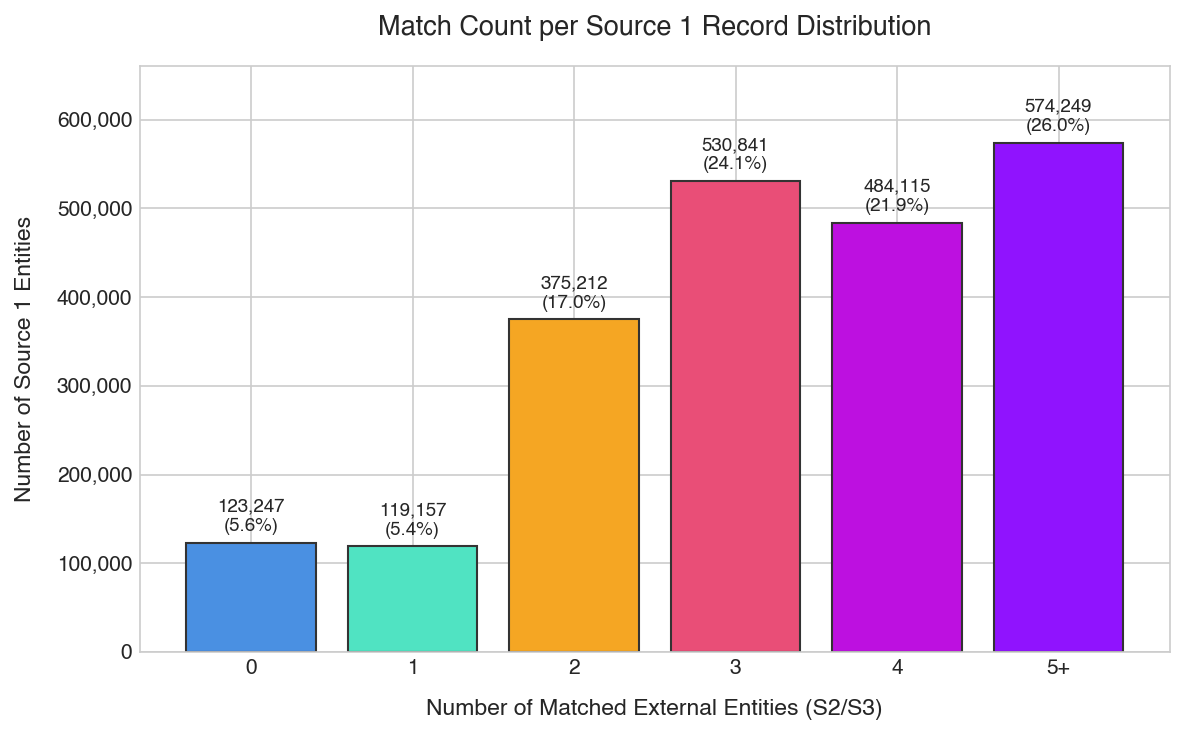

In [5]:
# Group into match buckets (0, 1, 2, 3, 4, 5+)
def bucket_match_count(c):
    if c >= 5:
        return '5+'
    return str(c)

df_gt['match_bucket'] = df_gt['match_count'].apply(bucket_match_count)
bucket_order = ['0', '1', '2', '3', '4', '5+']
bucket_counts = df_gt['match_bucket'].value_counts().reindex(bucket_order, fill_value=0)
bucket_pcts = bucket_counts / total_s1 * 100

summary_match_df = pd.DataFrame({
    'Match Bucket': bucket_order,
    'S1 Entity Count': bucket_counts.values,
    'Percentage (%)': [f"{p:.2f}%" for p in bucket_pcts]
})
display(summary_match_df)

# Plot Match Distribution Bar Chart
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
bars = ax.bar(bucket_order, bucket_counts.values, color=['#4A90E2', '#50E3C2', '#F5A623', '#E94E77', '#BD10E0', '#9013FE'], edgecolor='#333333', linewidth=1)
ax.set_title('Match Count per Source 1 Record Distribution', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Number of Matched External Entities (S2/S3)', fontsize=11, labelpad=10)
ax.set_ylabel('Number of Source 1 Entities', fontsize=11, labelpad=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

for bar, count, pct in zip(bars, bucket_counts.values, bucket_pcts):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + max(bucket_counts.values)*0.015,
            f"{count:,}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=9, fontweight='semibold')

ax.set_ylim(0, max(bucket_counts.values) * 1.15)
plt.tight_layout()
plt.savefig('eda_assets/match_count_distribution.png')
plt.show()


In [6]:
# Matched IDs Breakdown (S2 vs S3)
all_matched_ids = [m for sublist in df_gt['matches_list'] for m in sublist]
total_matched_ids = len(all_matched_ids)
s2_matched_ids = [m for m in all_matched_ids if m.startswith('S2-')]
s3_matched_ids = [m for m in all_matched_ids if m.startswith('S3-')]
other_matched_ids = [m for m in all_matched_ids if not (m.startswith('S2-') or m.startswith('S3-'))]

print(f"f) Total Matched Entity References: {total_matched_ids:,}")
print(f"   Matches in Source 2: {len(s2_matched_ids):,} ({len(s2_matched_ids)/total_matched_ids*100:.2f}%)")
print(f"   Matches in Source 3: {len(s3_matched_ids):,} ({len(s3_matched_ids)/total_matched_ids*100:.2f}%)")
print(f"   Invalid / Other Prefixes: {len(other_matched_ids):,}")

# Consistency between train_source1.tsv and train_ground_truth.tsv
s1_ids_set = set(df_s1['entity_id'])
gt_s1_ids_set = set(df_gt['source1_entity_id'])
print(f"\ng) S1 IDs in GT but missing in Source 1: {len(gt_s1_ids_set - s1_ids_set)}")
print(f"   S1 IDs in Source 1 but missing in GT: {len(s1_ids_set - gt_s1_ids_set)}")


f) Total Matched Entity References: 7,638,365
   Matches in Source 2: 3,693,619 (48.36%)
   Matches in Source 3: 3,944,746 (51.64%)
   Invalid / Other Prefixes: 0



g) S1 IDs in GT but missing in Source 1: 0
   S1 IDs in Source 1 but missing in GT: 0


In [7]:
# Load and check Source 2
print("Loading Source 2...")
df_s2 = pd.read_csv(s2_path, sep='\t')
print(f"Source 2 Shape: {df_s2.shape[0]:,} rows, {df_s2.shape[1]} columns")
print("Source 2 Nulls:\n", df_s2.isnull().sum())
print("Source 2 Duplicate IDs:", df_s2['entity_id'].duplicated().sum())
print("Source 2 All IDs start with 'S2-':", df_s2['entity_id'].str.startswith('S2-').all())

set_s2_matched = set(s2_matched_ids)
s2_all_ids = set(df_s2['entity_id'])
orphaned_s2 = set_s2_matched - s2_all_ids
print(f"\nh) Orphaned S2 references in Ground Truth: {len(orphaned_s2)}")

s2_ref_count = len(s2_all_ids.intersection(set_s2_matched))
s2_noise_count = len(df_s2) - s2_ref_count
print(f"i) S2 records referenced in GT (True Matches): {s2_ref_count:,} ({s2_ref_count/len(df_s2)*100:.2f}%)")
print(f"   S2 unreferenced records (Noise Distractors): {s2_noise_count:,} ({s2_noise_count/len(df_s2)*100:.2f}%)")


Loading Source 2...


Source 2 Shape: 5,034,616 rows, 4 columns
Source 2 Nulls:
 entity_id                0
business_name            2
business_address    168967
country                  0
dtype: int64


Source 2 Duplicate IDs: 0


Source 2 All IDs start with 'S2-': True



h) Orphaned S2 references in Ground Truth: 0
i) S2 records referenced in GT (True Matches): 3,693,619 (73.36%)
   S2 unreferenced records (Noise Distractors): 1,340,997 (26.64%)


In [8]:
# Load and check Source 3
print("Loading Source 3...")
df_s3 = pd.read_csv(s3_path, sep='\t')
print(f"Source 3 Shape: {df_s3.shape[0]:,} rows, {df_s3.shape[1]} columns")
print("Source 3 Nulls:\n", df_s3.isnull().sum())
print("Source 3 Duplicate IDs:", df_s3['entity_id'].duplicated().sum())
print("Source 3 All IDs start with 'S3-':", df_s3['entity_id'].str.startswith('S3-').all())

set_s3_matched = set(s3_matched_ids)
s3_all_ids = set(df_s3['entity_id'])
orphaned_s3 = set_s3_matched - s3_all_ids
print(f"\nh) Orphaned S3 references in Ground Truth: {len(orphaned_s3)}")

s3_ref_count = len(s3_all_ids.intersection(set_s3_matched))
s3_noise_count = len(df_s3) - s3_ref_count
print(f"i) S3 records referenced in GT (True Matches): {s3_ref_count:,} ({s3_ref_count/len(df_s3)*100:.2f}%)")
print(f"   S3 unreferenced records (Noise Distractors): {s3_noise_count:,} ({s3_noise_count/len(df_s3)*100:.2f}%)")


Loading Source 3...


Source 3 Shape: 5,285,603 rows, 4 columns
Source 3 Nulls:
 entity_id                0
business_name           13
business_address    175916
country                  0
dtype: int64


Source 3 Duplicate IDs: 0


Source 3 All IDs start with 'S3-': True



h) Orphaned S3 references in Ground Truth: 0
i) S3 records referenced in GT (True Matches): 3,944,746 (74.63%)
   S3 unreferenced records (Noise Distractors): 1,340,857 (25.37%)


---
## TASK 3: Country Distribution Analysis & Generalization Warning

We inspect country formatting and distributions across all three sources.

> **CRITICAL WARNING:** The training set contains only `US` and `India`. However, the **test set contains unseen countries (e.g. `France`)**. Pipelines must treat `country` as an open string and avoid hardcoded country allowlists.


,Source 1 Count,Source 1 %,Source 2 Count,Source 2 %,Source 3 Count,Source 3 %
country,,,,,,
US,1323633,59.98,3016817,59.92,3170056,59.98
India,883188,40.02,2017799,40.08,2115547,40.02


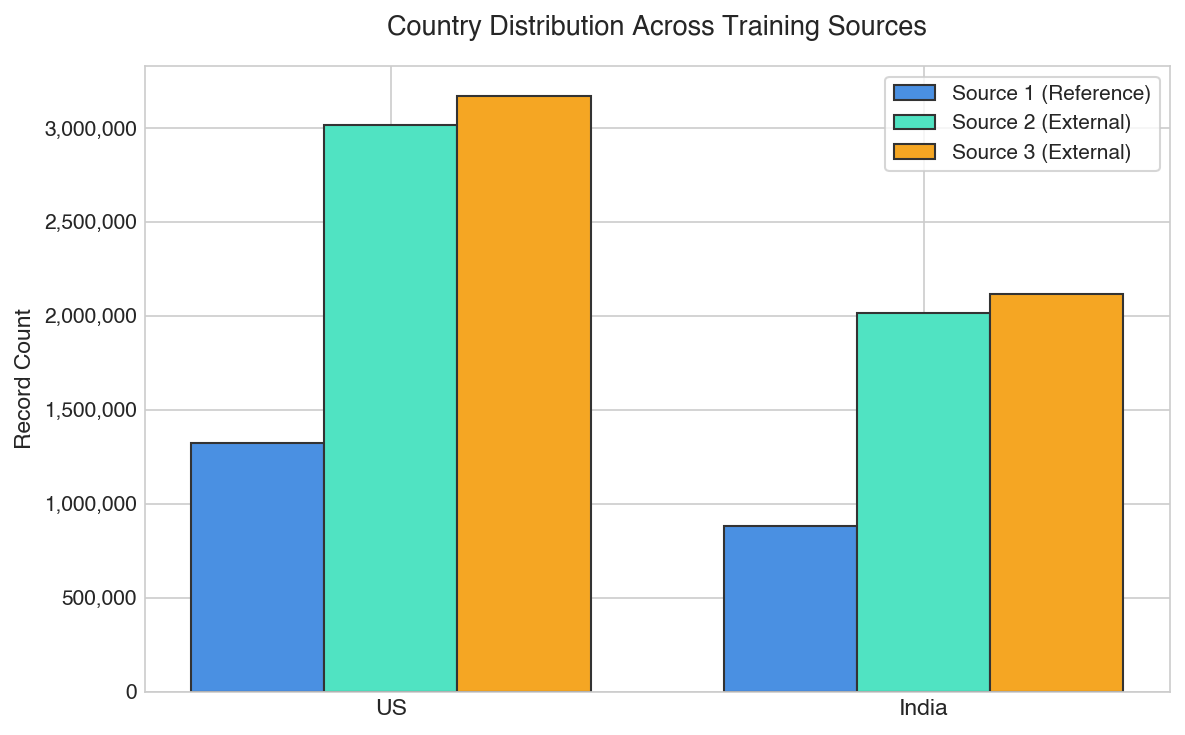

In [9]:
s1_country_vc = df_s1['country'].value_counts(dropna=False)
s2_country_vc = df_s2['country'].value_counts(dropna=False)
s3_country_vc = df_s3['country'].value_counts(dropna=False)

country_table = pd.DataFrame({
    'Source 1 Count': s1_country_vc,
    'Source 1 %': (s1_country_vc / len(df_s1) * 100).round(2),
    'Source 2 Count': s2_country_vc,
    'Source 2 %': (s2_country_vc / len(df_s2) * 100).round(2),
    'Source 3 Count': s3_country_vc,
    'Source 3 %': (s3_country_vc / len(df_s3) * 100).round(2)
}).fillna(0)

display(country_table)

# Plot Country Distribution
country_counts_df = pd.DataFrame({
    'Source 1': s1_country_vc,
    'Source 2': s2_country_vc,
    'Source 3': s3_country_vc
}).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
x = np.arange(len(country_counts_df))
width = 0.25

ax.bar(x - width, country_counts_df['Source 1'], width, label='Source 1 (Reference)', color='#4A90E2', edgecolor='#333333')
ax.bar(x, country_counts_df['Source 2'], width, label='Source 2 (External)', color='#50E3C2', edgecolor='#333333')
ax.bar(x + width, country_counts_df['Source 3'], width, label='Source 3 (External)', color='#F5A623', edgecolor='#333333')

ax.set_title('Country Distribution Across Training Sources', fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(country_counts_df.index, fontsize=11, fontweight='semibold')
ax.set_ylabel('Record Count', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: f"{int(y):,}"))
ax.legend(frameon=True, fontsize=10)
plt.tight_layout()
plt.savefig('eda_assets/country_distribution.png')
plt.show()


---
## TASK 6: Length and Token Statistics

We compute character length and whitespace token counts for `business_name` and `business_address` across all sources to inform blocking and model context window parameters.


In [10]:
def get_field_stats(series, source_name, field_name):
    clean_series = series.fillna('').astype(str)
    char_lens = clean_series.str.len()
    tok_counts = np.where(char_lens == 0, 0, clean_series.str.count(' ') + 1)
    
    stats = {
        'Source': source_name,
        'Field': field_name,
        'Char Mean': float(char_lens.mean()),
        'Char Median': float(char_lens.median()),
        'Char Min': int(char_lens.min()),
        'Char Max': int(char_lens.max()),
        'Token Mean': float(tok_counts.mean()),
        'Token Median': float(np.median(tok_counts)),
        'Token Min': int(tok_counts.min()),
        'Token Max': int(tok_counts.max()),
    }
    return stats, char_lens.values, tok_counts

s1_name_stats, s1_name_len, s1_name_tok = get_field_stats(df_s1['business_name'], 'Source 1', 'business_name')
s1_addr_stats, s1_addr_len, s1_addr_tok = get_field_stats(df_s1['business_address'], 'Source 1', 'business_address')

s2_name_stats, s2_name_len, s2_name_tok = get_field_stats(df_s2['business_name'], 'Source 2', 'business_name')
s2_addr_stats, s2_addr_len, s2_addr_tok = get_field_stats(df_s2['business_address'], 'Source 2', 'business_address')

s3_name_stats, s3_name_len, s3_name_tok = get_field_stats(df_s3['business_name'], 'Source 3', 'business_name')
s3_addr_stats, s3_addr_len, s3_addr_tok = get_field_stats(df_s3['business_address'], 'Source 3', 'business_address')

stats_table = pd.DataFrame([
    s1_name_stats, s2_name_stats, s3_name_stats,
    s1_addr_stats, s2_addr_stats, s3_addr_stats
])
display(stats_table.round(2))


,Source,Field,Char Mean,Char Median,Char Min,Char Max,Token Mean,Token Median,Token Min,Token Max
0,Source 1,business_name,24.03,24.0,3,105,3.55,4.0,1,16
1,Source 2,business_name,25.10,25.0,0,104,3.61,4.0,0,16
2,Source 3,business_name,25.20,25.0,0,123,3.63,4.0,0,18
3,Source 1,business_address,52.07,41.0,11,256,8.03,7.0,2,43
4,Source 2,business_address,46.23,37.0,0,249,7.31,6.0,0,46
5,Source 3,business_address,46.71,42.0,0,240,7.17,6.0,0,43


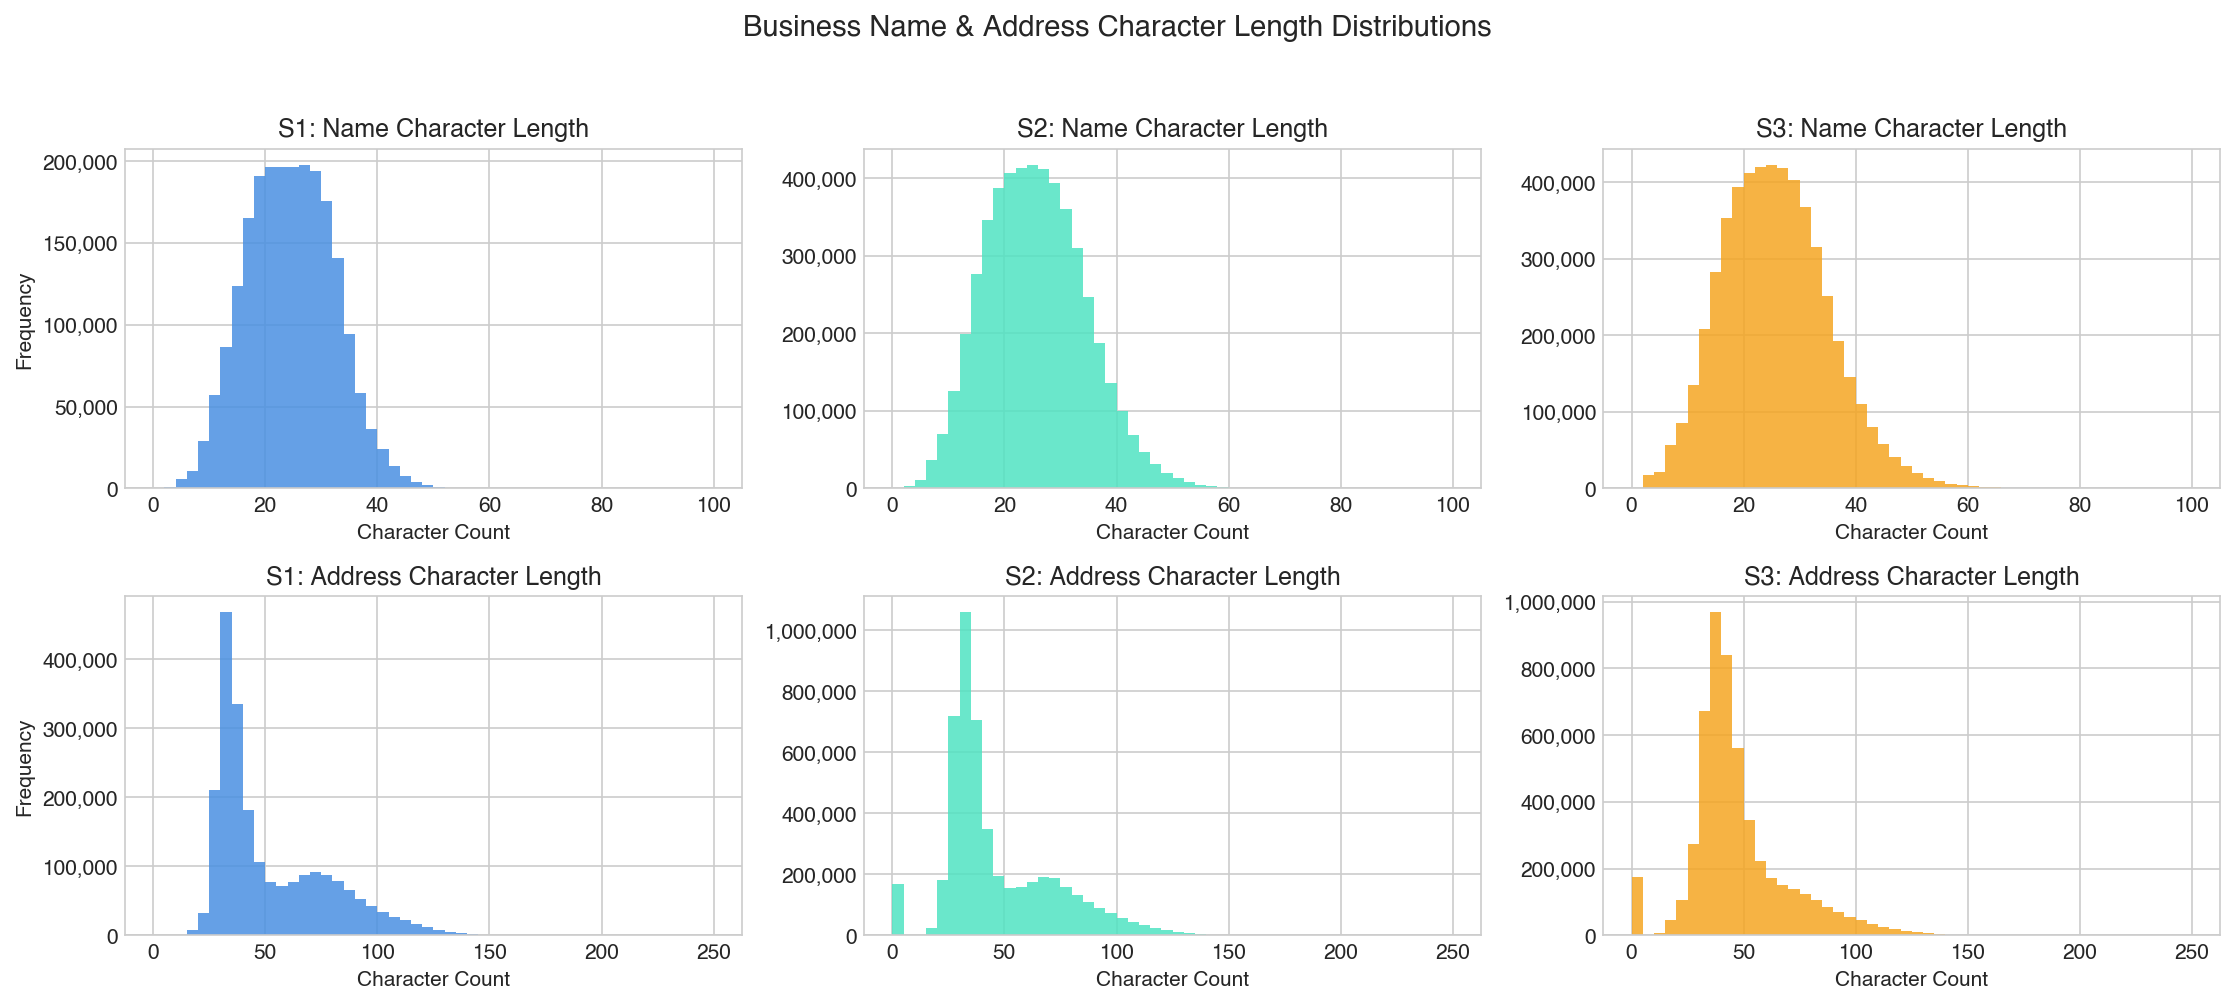

3009

In [11]:
# Plot Character Length Distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 7), dpi=150)
axes[0, 0].hist(s1_name_len, bins=50, range=(0, 100), color='#4A90E2', alpha=0.85)
axes[0, 0].set_title('S1: Name Character Length', fontweight='bold')
axes[0, 0].set_ylabel('Frequency')
axes[0, 1].hist(s2_name_len, bins=50, range=(0, 100), color='#50E3C2', alpha=0.85)
axes[0, 1].set_title('S2: Name Character Length', fontweight='bold')
axes[0, 2].hist(s3_name_len, bins=50, range=(0, 100), color='#F5A623', alpha=0.85)
axes[0, 2].set_title('S3: Name Character Length', fontweight='bold')

axes[1, 0].hist(s1_addr_len, bins=50, range=(0, 250), color='#4A90E2', alpha=0.85)
axes[1, 0].set_title('S1: Address Character Length', fontweight='bold')
axes[1, 0].set_ylabel('Frequency')
axes[1, 1].hist(s2_addr_len, bins=50, range=(0, 250), color='#50E3C2', alpha=0.85)
axes[1, 1].set_title('S2: Address Character Length', fontweight='bold')
axes[1, 2].hist(s3_addr_len, bins=50, range=(0, 250), color='#F5A623', alpha=0.85)
axes[1, 2].set_title('S3: Address Character Length', fontweight='bold')

for row in axes:
    for ax in row:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: f"{int(y):,}"))
        ax.set_xlabel('Character Count')

plt.suptitle('Business Name & Address Character Length Distributions', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('eda_assets/length_distributions.png')
plt.show()

# Clean up large array memory
del s1_name_len, s1_name_tok, s1_addr_len, s1_addr_tok
del s2_name_len, s2_name_tok, s2_addr_len, s2_addr_tok
del s3_name_len, s3_name_tok, s3_addr_len, s3_addr_tok
gc.collect()


---
## TASK 4 & 5: Business Name and Address Noise Cataloging

We inspect sampled pairs of Source 1 canonical records and their true matching records in Source 2 and Source 3 to identify empirical noise patterns.
The complete catalogs are saved in:
- `eda_assets/name_noise_catalog.md`
- `eda_assets/address_noise_catalog.md`


In [12]:
# Load pre-extracted sampled pairs
with open('eda_assets/sampled_pairs.json', 'r') as f:
    sampled_pairs = json.load(f)

print(f"Displaying 10 sample true match pairs/triples across buckets:\n")
for i, item in enumerate(sampled_pairs[:10]):
    print(f"=== SAMPLE {i+1} [ID: {item['s1_id']}] ===")
    print(f"  S1 Canonical:  Name: '{item['s1_name']}'")
    print(f"                 Addr: '{item['s1_address']}' | Country: {item['s1_country']}")
    for m in item['matches']:
        print(f"  -> Match [{m['matched_id']}]: Name: '{m['matched_name']}'")
        print(f"                       Addr: '{m['matched_address']}' | Country: {m['matched_country']}")
    print()


Displaying 10 sample true match pairs/triples across buckets:

=== SAMPLE 1 [ID: S1-994431408] ===
  S1 Canonical:  Name: 'All Industrial Holdings'
                 Addr: 'Dry Branch, 1824 Cabin Creek Road, WV' | Country: US
  -> Match [S2-78663308]: Name: 'All Industrial Inc'
                       Addr: '#1824 CABIN CREEK RD, DRY BRANCH, WV' | Country: US

=== SAMPLE 2 [ID: S1-800413488] ===
  S1 Canonical:  Name: 'Services Aeon Technologies Private Limited'
                 Addr: 'Ag-572 Shalimar Bagh, Delhi, North Delhi, Delhi' | Country: India
  -> Match [S3-429525528]: Name: 'Services Áeon Technologies-Private Limited'
                       Addr: 'Ag-4-572 Shalimar Bagh, North Delhi, Delhi, DL' | Country: India

=== SAMPLE 3 [ID: S1-352206944] ===
  S1 Canonical:  Name: 'Dental Partners LLC'
                 Addr: 'UT, 1330 375, Centerville, Unit F106' | Country: US
  -> Match [S2-387846404]: Name: '>> Dental Partners Llc'
                       Addr: 'CENTERVILLE, UT, 1330 375'

---
## TASK 7: Unreferenced "Noise" Record Characterization

We inspect external records in Source 2 and Source 3 that do not match any Source 1 business entity (representing ~26% of all external records).


In [13]:
with open('eda_assets/unreferenced_samples.json', 'r') as f:
    unref_samples = json.load(f)

print(f"Displaying 10 sampled unreferenced noise records from S2 and S3:\n")
for i, rec in enumerate(unref_samples[:10]):
    print(f"Noise {i+1}: [{rec['entity_id']}] ({rec['source']})")
    print(f"   Name:    '{rec['business_name']}'")
    print(f"   Address: '{rec['business_address']}'")
    print(f"   Country: {rec['country']}")
    print()


Displaying 10 sampled unreferenced noise records from S2 and S3:

Noise 1: [S2-577750704] (Source 2)
   Name:    'Malad Exports  Digital (W) Private Limited | www.maladexpo.com'
   Address: 'BLOCK G-#31 B-1 / B-11, ASHIRWAD APARTMENT, VISHAL NAGAR, MITH CHOWKEY, MARVE ROAD, MALAD (W), Maharashtra'
   Country: India

Noise 2: [S2-972970275] (Source 2)
   Name:    'Trinh Couriers Ltd'
   Address: '929 BUILDING, FORT IRWIN, CA, NULL'
   Country: US

Noise 3: [S2-962392308] (Source 2)
   Name:    'Smith Kodiak Group'
   Address: '36392 Derby Downs Drive, SOLON, OH'
   Country: US

Noise 4: [S2-2101517] (Source 2)
   Name:    'Empire Animal Hospital Central Corp'
   Address: 'OK, NINNEKAH CDP, ##913 Highway 277'
   Country: US

Noise 5: [S2-53597599] (Source 2)
   Name:    'यूनिवर्सल कंसल्टेंट्स प्राइवेट लिमिटेड'
   Address: 'NO 84- KALPANA RAY, BEGUSARAI, Bihar'
   Country: India

Noise 6: [S2-91381987] (Source 2)
   Name:    'Deepam Solutionsprivate (India) Infratech Prívate [Limited]'
  

---
## Phase 1 Deliverables Summary

All deliverables for Phase 1 are saved and accessible:
- **Notebook:** `notebooks/01_eda.ipynb`
- **Charts:** `notebooks/eda_assets/*.png`
- **Name Noise Catalog:** `notebooks/eda_assets/name_noise_catalog.md`
- **Address Noise Catalog:** `notebooks/eda_assets/address_noise_catalog.md`
- **Consolidated Summary:** `notebooks/eda_assets/eda_summary.md`
